In [37]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## 1. Parameter & Initialisierung

### Cosinus Fenster Allgemein

$$ w(n) = \sum_{n=0}^{\infty} c_n \cdot \cos(\omega_0 \cdot n) = c_0 + c_1 \cdot \cos(\omega_0) + c_2 \cdot \cos(2 \cdot \omega_0) + c_3 \cdot  \cos(3 \cdot \omega_0) + \dots $$

In [42]:
N = 100
# MATLAB: fvn = 1-N:N-1 (Länge 199, symmetrisch um 0)
# Python: arange ist exklusiv am Ende, daher N (nicht N-1) als Stop
n = np.arange(1-N, N) 

# Koeffizienten-Definition
# Struktur: [DC-Anteil, Cos-Anteil 1, Cos-Anteil 2]
coeff_dict = {
    'Rectangular': [1.0,  0.0,  0.0],
    'Hanning':     [0.5,  0.5,  0.0],
    'Hamming':     [0.54, 0.46, 0.0],
    'Blackman':    [0.42, 0.5,  0.08]
}

colors = ['red', 'green', 'blue', 'black']

## 2. Berechnung (Zeit- & Frequenzbereich)

In [43]:
# Wir speichern die Ergebnisse in Listen/Dictionaries
results = dict()

FFT_SIZE = 1024
# Plot Frequenzbereich
# x-Achse ist hier einfach der Index 0 bis 1024 (wie im Matlab Skript)
f_axis = np.arange(-FFT_SIZE//2, FFT_SIZE//2)

for name, c in coeff_dict.items():
    # a) Zeitbereich w(n)
    # Formel: c[0] + c[1]*cos(...) + c[2]*cos(...)
    w_n = (
        c[0] +#np.cos(0 * np.pi * n / (N - 1))
        c[1] * np.cos(1 * np.pi * n / (N - 1)) + 
        c[2] * np.cos(2 * np.pi * n / (N - 1))
    )
    
    # b) Frequenzbereich W(jw)
    # FFT mit Zero-Padding auf 1024
    W_raw = np.fft.fft(w_n, FFT_SIZE)
    
    # Normierung auf 0 dB (Teilen durch Summe der Fensterkoeffizienten)
    W_norm = W_raw / np.sum(w_n)
    
    # fftshift sortiert Frequenzen: 0Hz in die Mitte schieben
    W_shifted = np.fft.fftshift(W_norm)

    W_abs = np.abs(W_shifted)
    
    results[name] = dict(t = w_n, f = W_abs)
    # results[name] = {'t': w_n, 'f': W_abs}

## 3. Visualisierung mit Plotly

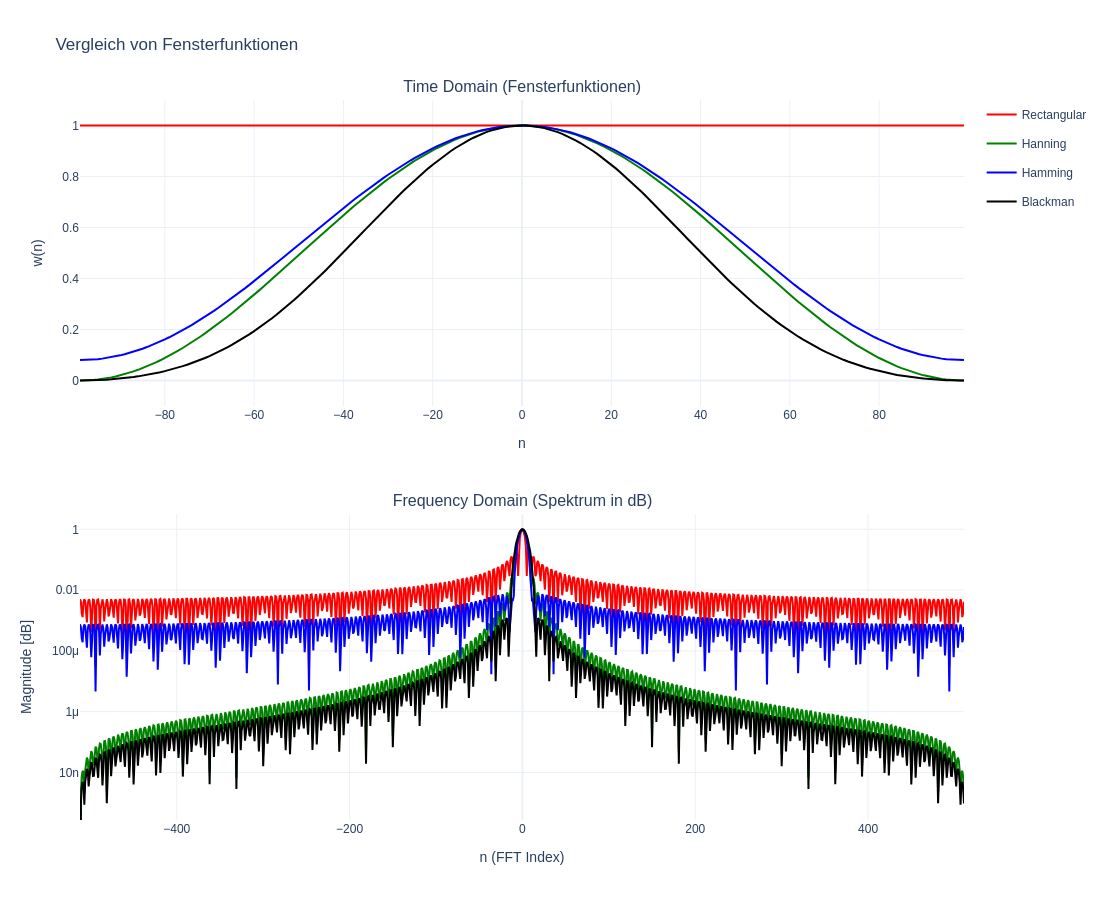

In [44]:
DB = True

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=(
        "Time Domain (Fensterfunktionen)", 
        "Frequency Domain (Spektrum" + (" in dB)" if DB else ")")
    ),
    vertical_spacing=0.15
)

# Iteration über die Ergebnisse und Plotten
for i, (name, data) in enumerate(results.items()):
    col = colors[i]
    
    # Plot Zeitbereich
    fig.add_trace(
        go.Scatter(
            x=n,
            y=data['t'],
            name=name,
            line=dict(color=col, width=2), 
            legendgroup=name
        ), row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=f_axis,
            y=data['f'],
            name=name,
            line=dict(color=col, width=2),
            legendgroup=name,
            showlegend=False
        ), row=2, col=1
    )

# Layout Anpassungen (ähnlich zu Matlab Eigenschaften)
fig.update_layout(
    # width=900,
    height=900, 
    title_text="Vergleich von Fensterfunktionen",
    template="plotly_white",
    hovermode="x unified" # Zeigt alle Werte an einer x-Position gleichzeitig
)

# Achsenbeschriftungen und Limits
# Zeitbereich
fig.update_xaxes(title_text="n", row=1, col=1)
fig.update_yaxes(title_text="w(n)", range=[-0.1, 1.1], row=1, col=1)

# Frequenzbereich
fig.update_xaxes(title_text="n (FFT Index)", range=[f_axis[0], f_axis[-1]], row=2, col=1)
fig.update_yaxes(title_text="Magnitude" + (" [dB]" if DB else ""), row=2, col=1, type="log" if DB else "linear")

fig.show()